In [2]:
# 1. SYSTEM IMPORTS (Crucial to define 'os' and 'sys' first)
import os
import sys
import time
from os.path import sep
# Plotting
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Math + stats
import numpy as np
import pandas as pd
from scipy.stats import binom
from scipy.stats import t
import scipy.stats as stats

# Logistics
from os.path import sep
from tqdm import tqdm
import sys
import time

# Local modules
# ==============================================================================
# SYSTEM COMPATIBILITY SECTION
# ==============================================================================
# PASTE YOUR FOLDER PATH HERE (Keep the 'r' before the quotes)
# file_path_manual = r"C:\Users\CEGIS FOUNDATION\New folder\GitHub\discsim\api\utils\Pre Survey Nested Simulation"
# new loc in new lap
file_path_manual=r"C:\Users\CEGIS\Desktop\work\GitHub\discsim\api\utils\Pre Survey Nested Simulation"
# "C:\Users\CEGIS\Desktop\work\GitHub\discsim\api\utils\Pre Survey Nested Simulation"

# 1. Register the path
if os.path.exists(file_path_manual):
    if file_path_manual not in sys.path:
        sys.path.append(file_path_manual)
    print(f"✅ Path Registered: {file_path_manual}")
else:
    print(f"❌ ERROR: Path not found! Please check the folder path.")

# 2. Import Local Modules using the correct subfolder names
try:
    # We must import from the 'ecd_nested_simulation_functions' subfolder
    import ecd_nested_simulation_functions.generate_ecd_dummy_data as generate_ecd_dummy_data
    import ecd_nested_simulation_functions.ecd_sampling_strategy as ecd_sampling_strategy
    #import ecd_nested_simulation_functions.generate_ecd_dummy_data2 as generate_ecd_dummy_data2
    # Try to import the DTA extractor (it's usually in the main folder)
    try:
        from AS_extract_data_from_dta_file import extract_data_from_dta
    except ImportError:
        # Fallback to standard pandas reader if specific file is missing
        def extract_data_from_dta(path): return pd.read_stata(path)
        
    print("✅ ECD Simulation modules imported successfully.")
    
except ImportError as e:
    print(f"❌ IMPORT ERROR: {e}")
    print("Hint: Check if there is a folder named 'ecd_nested_simulation_functions' inside your manual path.")

# Enable re-load of local modules every time they are called
%load_ext autoreload
%autoreload 2
%aimport numpy 
%aimport pandas

✅ Path Registered: C:\Users\CEGIS\Desktop\work\GitHub\discsim\api\utils\Pre Survey Nested Simulation
✅ ECD Simulation modules imported successfully.


In [3]:
# Loading the anthro lms who data 
# 11;15 am jan 30 friday good
import pandas as pd
import os

# 1. SETUP PATHS
# We define the base folder to keep the code clean
# BASE_DIR = r"C:\Users\CEGIS FOUNDATION\New folder\GitHub\igrowup_update"

BASE_DIR=r"C:\Users\CEGIS\Desktop\work\GitHub\igrowup_update"

def extract_data_from_dta(filename):
    """
    Helper function to join path and read Stata (.dta) files
    """
    full_path = os.path.join(BASE_DIR, filename)
    if not os.path.exists(full_path):
        raise FileNotFoundError(f"File not found: {full_path}")
    print(f"Loading: {filename}...")
    return pd.read_stata(full_path)

# 2. SET PARAMETERS
num_children = 10000
girl_ratio = 0.5
num_timepoints = 1
time_lags = []
min_age = 0 * 365
max_age = 5 * 365

# 3. LOAD WHO STANDARDS
print("--- Loading WHO Growth Standards ---")

# Load HAZ parameters (Length/Height-for-age)
# Corresponds to: lenanthro.dta
haz_params = extract_data_from_dta('lenanthro.dta')

# Load WAZ parameters (Weight-for-age)
# Corresponds to: weianthro.dta
waz_params = extract_data_from_dta('weianthro.dta')

# Load WHZ parameters (Weight-for-Length -> Lying)
# Corresponds to: wflanthro.dta
whz_params_lying = extract_data_from_dta('wflanthro.dta')

# Load WHZ parameters (Weight-for-Height -> Standing)
# Corresponds to: wfhanthro.dta
whz_params_standing = extract_data_from_dta('wfhanthro.dta')

print("\nSuccess! All parameters loaded.")
print(f"HAZ Shape: {haz_params.shape}")
print(f"WAZ Shape: {waz_params.shape}")

--- Loading WHO Growth Standards ---
Loading: lenanthro.dta...
Loading: weianthro.dta...
Loading: wflanthro.dta...
Loading: wfhanthro.dta...

Success! All parameters loaded.
HAZ Shape: (3714, 6)
WAZ Shape: (3714, 5)


may 22 friday validation results

In [22]:
import os
import time
import random
import numpy as np
import pandas as pd
from tqdm import tqdm

# ==========================================
# 0. SETUP DIRECTORY
# ==========================================
# Use a raw string (r"") for Windows paths to prevent backslash errors
base_dir = r"C:\Users\CEGIS\Documents\GitHub\discsim\audit_dashboard"
output_dir = os.path.join(base_dir, "validation_results")

# Create the validation_results folder if it does not exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"📁 Created new directory: {output_dir}")
else:
    print(f"📁 Directory ready: {output_dir}")

# ==========================================
# 1. SET SIZE & SCENARIO
# ==========================================
N_L1_SUPERVISORS = 10
N_L0_CENTERS_PER_L1 = 10
N_CHILDREN = 15

# Scenario: "1_Good_L0_Good_L1"
scene_name = "1_Bad_L0_Good_L1"
stunting_under_report = 20
bunch_factor = 0.1
copy_percent = 5
collusion_index = 0.05

# Biological parameters
rho_val = 0.7
err_ht, err_wt = 0, 0  # Measurement Error OFF for this scenario

print(f"🚀 INITIATING SINGLE UNIVERSE GENERATION: {scene_name} | rho = {rho_val}")
start_time = time.time()

# ==========================================
# 2. DEFINE BIOLOGICAL TRUTHS
# ==========================================
common_real_params = {
    'girl_ratio': 0.5, 
    'min_age': 0, 
    'max_age': 1790, 
    'num_timepoints': 1, 
    'time_lags': [],
    'percent_stunting': 35, 
    'percent_underweight': 33,
    'rho': rho_val
}

# Lock both numpy and standard random seeds for 100% perfect reproducibility
np.random.seed(42)
random.seed(42)

# ==========================================
# 3. BUILD THE PROFILES (Instructions)
# ==========================================
L0_params_list, L1_params_list, L2_params_dict = generate_ecd_dummy_data.generate_nested_distortion_parameters(
    n_L1s=N_L1_SUPERVISORS, 
    n_L0s_per_L1=N_L0_CENTERS_PER_L1,
    real_percent_stunting=35, 
    real_percent_underweight=33,
    
    # Scenario Injections
    mean_percent_under_reporting_stunting=stunting_under_report, 
    mean_percent_under_reporting_underweight=stunting_under_report, 
    mean_bunch_factor_haz=bunch_factor, 
    mean_bunch_factor_waz=bunch_factor, 
    mean_bunch_factor_whz=bunch_factor,
    mean_percent_copy=copy_percent, 
    mean_collusion_index=collusion_index,
    
    # Base Variances
    sd_across_units_percent_under_reporting_stunting=2, 
    sd_across_units_percent_under_reporting_underweight=2,
    sd_within_units_percent_under_reporting_stunting=1, 
    sd_within_units_percent_under_reporting_underweight=1,
    sd_across_units_bunch_factor_haz=0.01, 
    sd_across_units_bunch_factor_waz=0.01, 
    sd_across_units_bunch_factor_whz=0.01,
    sd_within_units_bunch_factor_haz=0.01, 
    sd_within_units_bunch_factor_waz=0.01, 
    sd_within_units_bunch_factor_whz=0.01,
    sd_percent_copy=2, 
    sd_collusion_index=0.02,
    
    # Measurement Errors
    error_sd_height_all_L0s=err_ht, error_sd_weight_all_L0s=err_wt,
    error_sd_height_L1=err_ht, error_sd_weight_L1=err_wt, 
    error_sd_height_L2=err_ht, error_sd_weight_L2=err_wt, 
    
    # Time Lags
    mean_time_lag_L1=15, 
    mean_time_lag_L2=30
)

# ==========================================
# 4. GENERATE THE DATA
# ==========================================
nested_measurements = generate_ecd_dummy_data.generate_nested_measurements(
    real_params=common_real_params, 
    L0_params_list=L0_params_list, 
    L1_params_list=L1_params_list, 
    L2_params_dict=L2_params_dict,
    n_L1s=N_L1_SUPERVISORS, 
    n_L0s_per_L1=N_L0_CENTERS_PER_L1, 
    n_children_per_L0=N_CHILDREN,
    n_children_L1=N_CHILDREN, 
    n_children_L2=N_CHILDREN,
    haz_params=haz_params, 
    waz_params=waz_params, 
    whz_params_lying=whz_params_lying, 
    whz_params_standing=whz_params_standing, 
    make_plots=False
)

# ==========================================
# 5. FLATTEN AND SAVE
# ==========================================
all_children_records = []
for L1_id, L1_data in tqdm(nested_measurements.items(), desc="Flattening Data"):
    if L1_id == 'metadata': continue
    for L0_id, L0_data in L1_data.items():
        if L0_id == 'L1_info': continue
        
        # Standardize column names
        df_real = L0_data['real']['data'].copy().rename(columns={'haz': 'real_haz', 'waz': 'real_waz', 'whz': 'real_whz', 'height': 'real_height', 'weight': 'real_weight', 'age': 'real_age_days'})
        df_L0 = L0_data['L0']['data'].copy().rename(columns={'haz': 'L0_haz', 'waz': 'L0_waz', 'whz': 'L0_whz', 'height': 'L0_height', 'weight': 'L0_weight'})
        df_L1 = L0_data['L1']['data'].copy().rename(columns={'haz': 'L1_haz', 'waz': 'L1_waz', 'whz': 'L1_whz', 'height': 'L1_height', 'weight': 'L1_weight', 'age': 'L1_age_days'})
        df_L2 = L0_data['L2']['data'].copy().rename(columns={'haz': 'L2_haz', 'waz': 'L2_waz', 'whz': 'L2_whz', 'height': 'L2_height', 'weight': 'L2_weight', 'age': 'L2_age_days'})
        
        # Merge all levels for the child into one row
        merged_df = df_real[['child_id', 'gender', 'real_age_days', 'real_height', 'real_weight', 'real_haz', 'real_waz', 'real_whz', 'loh']].merge(
            df_L0[['child_id', 'L0_height', 'L0_weight', 'L0_haz', 'L0_waz', 'L0_whz']], on='child_id', how='left').merge(
            df_L1[['child_id', 'L1_age_days', 'L1_height', 'L1_weight', 'L1_haz', 'L1_waz', 'L1_whz']], on='child_id', how='left').merge(
            df_L2[['child_id', 'L2_age_days', 'L2_height', 'L2_weight', 'L2_haz', 'L2_waz', 'L2_whz']], on='child_id', how='left')
        
        merged_df['L1_id'] = L1_id
        merged_df['L0_id'] = L0_id
        all_children_records.append(merged_df)

golden_df = pd.concat(all_children_records, ignore_index=True)

# Save to Parquet inside the validation_results folder
output_filename = os.path.join(output_dir, f'single_universe_{scene_name}_rho_{rho_val}.parquet')
golden_df.to_parquet(output_filename, engine='pyarrow')

print(f"\n✅ Single Universe Generated and Saved in {(time.time() - start_time) / 60:.2f} minutes!")
print(f"File Location: {output_filename}")
print(f"Total Rows: {len(golden_df)}")

📁 Directory ready: C:\Users\CEGIS\Documents\GitHub\discsim\audit_dashboard\validation_results
🚀 INITIATING SINGLE UNIVERSE GENERATION: 1_Bad_L0_Good_L1 | rho = 0.7


Flattening Data: 100%|██████████| 10/10 [00:01<00:00,  6.65it/s]


✅ Single Universe Generated and Saved in 0.30 minutes!
File Location: C:\Users\CEGIS\Documents\GitHub\discsim\audit_dashboard\validation_results\single_universe_1_Bad_L0_Good_L1_rho_0.7.parquet
Total Rows: 1500


bad l0, bad l1

In [ ]:
import os
import time
import random
import numpy as np
import pandas as pd
from tqdm import tqdm

# ==========================================
# 0. SETUP DIRECTORY
# ==========================================
# Use a raw string (r"") for Windows paths to prevent backslash errors
base_dir = r"C:\Users\CEGIS\Documents\GitHub\discsim\audit_dashboard"
output_dir = os.path.join(base_dir, "validation_results")

# Create the validation_results folder if it does not exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"📁 Created new directory: {output_dir}")
else:
    print(f"📁 Directory ready: {output_dir}")

# ==========================================
# 1. SET SIZE & SCENARIO
# ==========================================
N_L1_SUPERVISORS = 10
N_L0_CENTERS_PER_L1 = 10
N_CHILDREN = 15

# Scenario: "1_Good_L0_Good_L1"
scene_name = "4_Bad_L0_Corrupt_L1"
stunting_under_report = 33
bunch_factor = 0.5
copy_percent = 50       # Supervisors copy 50% of the time!
collusion_index = 0.90  # Massive collusion!

err_ht, err_wt = 0.0, 0.0

print(f"🚀 INITIATING SINGLE UNIVERSE GENERATION: {scene_name} | rho = {rho_val}")
start_time = time.time()

# ==========================================
# 2. DEFINE BIOLOGICAL TRUTHS
# ==========================================
common_real_params = {
    'girl_ratio': 0.5, 
    'min_age': 0, 
    'max_age': 1790, 
    'num_timepoints': 1, 
    'time_lags': [],
    'percent_stunting': 35, 
    'percent_underweight': 33,
    'rho': rho_val
}

# Lock both numpy and standard random seeds for 100% perfect reproducibility
np.random.seed(42)
random.seed(42)

# ==========================================
# 3. BUILD THE PROFILES (Instructions)
# ==========================================
L0_params_list, L1_params_list, L2_params_dict = generate_ecd_dummy_data.generate_nested_distortion_parameters(
    n_L1s=N_L1_SUPERVISORS, 
    n_L0s_per_L1=N_L0_CENTERS_PER_L1,
    real_percent_stunting=35, 
    real_percent_underweight=33,
    
    # Scenario Injections
    mean_percent_under_reporting_stunting=stunting_under_report, 
    mean_percent_under_reporting_underweight=stunting_under_report, 
    mean_bunch_factor_haz=bunch_factor, 
    mean_bunch_factor_waz=bunch_factor, 
    mean_bunch_factor_whz=bunch_factor,
    mean_percent_copy=copy_percent, 
    mean_collusion_index=collusion_index,
    
    # Base Variances
    sd_across_units_percent_under_reporting_stunting=2, 
    sd_across_units_percent_under_reporting_underweight=2,
    sd_within_units_percent_under_reporting_stunting=1, 
    sd_within_units_percent_under_reporting_underweight=1,
    sd_across_units_bunch_factor_haz=0.01, 
    sd_across_units_bunch_factor_waz=0.01, 
    sd_across_units_bunch_factor_whz=0.01,
    sd_within_units_bunch_factor_haz=0.01, 
    sd_within_units_bunch_factor_waz=0.01, 
    sd_within_units_bunch_factor_whz=0.01,
    sd_percent_copy=2, 
    sd_collusion_index=0.02,
    
    # Measurement Errors
    error_sd_height_all_L0s=err_ht, error_sd_weight_all_L0s=err_wt,
    error_sd_height_L1=err_ht, error_sd_weight_L1=err_wt, 
    error_sd_height_L2=err_ht, error_sd_weight_L2=err_wt, 
    
    # Time Lags
    mean_time_lag_L1=15, 
    mean_time_lag_L2=30
)

# ==========================================
# 4. GENERATE THE DATA
# ==========================================
nested_measurements = generate_ecd_dummy_data.generate_nested_measurements(
    real_params=common_real_params, 
    L0_params_list=L0_params_list, 
    L1_params_list=L1_params_list, 
    L2_params_dict=L2_params_dict,
    n_L1s=N_L1_SUPERVISORS, 
    n_L0s_per_L1=N_L0_CENTERS_PER_L1, 
    n_children_per_L0=N_CHILDREN,
    n_children_L1=N_CHILDREN, 
    n_children_L2=N_CHILDREN,
    haz_params=haz_params, 
    waz_params=waz_params, 
    whz_params_lying=whz_params_lying, 
    whz_params_standing=whz_params_standing, 
    make_plots=False
)

# ==========================================
# 5. FLATTEN AND SAVE
# ==========================================
all_children_records = []
for L1_id, L1_data in tqdm(nested_measurements.items(), desc="Flattening Data"):
    if L1_id == 'metadata': continue
    for L0_id, L0_data in L1_data.items():
        if L0_id == 'L1_info': continue
        
        # Standardize column names
        df_real = L0_data['real']['data'].copy().rename(columns={'haz': 'real_haz', 'waz': 'real_waz', 'whz': 'real_whz', 'height': 'real_height', 'weight': 'real_weight', 'age': 'real_age_days'})
        df_L0 = L0_data['L0']['data'].copy().rename(columns={'haz': 'L0_haz', 'waz': 'L0_waz', 'whz': 'L0_whz', 'height': 'L0_height', 'weight': 'L0_weight'})
        df_L1 = L0_data['L1']['data'].copy().rename(columns={'haz': 'L1_haz', 'waz': 'L1_waz', 'whz': 'L1_whz', 'height': 'L1_height', 'weight': 'L1_weight', 'age': 'L1_age_days'})
        df_L2 = L0_data['L2']['data'].copy().rename(columns={'haz': 'L2_haz', 'waz': 'L2_waz', 'whz': 'L2_whz', 'height': 'L2_height', 'weight': 'L2_weight', 'age': 'L2_age_days'})
        
        # Merge all levels for the child into one row
        merged_df = df_real[['child_id', 'gender', 'real_age_days', 'real_height', 'real_weight', 'real_haz', 'real_waz', 'real_whz', 'loh']].merge(
            df_L0[['child_id', 'L0_height', 'L0_weight', 'L0_haz', 'L0_waz', 'L0_whz']], on='child_id', how='left').merge(
            df_L1[['child_id', 'L1_age_days', 'L1_height', 'L1_weight', 'L1_haz', 'L1_waz', 'L1_whz']], on='child_id', how='left').merge(
            df_L2[['child_id', 'L2_age_days', 'L2_height', 'L2_weight', 'L2_haz', 'L2_waz', 'L2_whz']], on='child_id', how='left')
        
        merged_df['L1_id'] = L1_id
        merged_df['L0_id'] = L0_id
        all_children_records.append(merged_df)

golden_df = pd.concat(all_children_records, ignore_index=True)

# Save to Parquet inside the validation_results folder
output_filename = os.path.join(output_dir, f'single_universe_{scene_name}_rho_{rho_val}.parquet')
golden_df.to_parquet(output_filename, engine='pyarrow')

print(f"\n✅ Single Universe Generated and Saved in {(time.time() - start_time) / 60:.2f} minutes!")
print(f"File Location: {output_filename}")
print(f"Total Rows: {len(golden_df)}")

row by row check

In [18]:
import pandas as pd

# Load the file you just generated
file_path = r"C:\Users\CEGIS\Documents\GitHub\discsim\audit_dashboard\validation_results\single_universe_1_Bad_L0_Good_L1_rho_0.7.parquet"
df_val = pd.read_parquet(file_path)

# Select specific columns to make the row-by-row validation easy to read
validation_columns = [
    'child_id',
    
    # 1. Check Time Passing (Ages)
    'real_age_days', 'L1_age_days', 'L2_age_days',
    
    # 2. Check Physical Measurements (Height)
    'real_height', 'L0_height', 'L1_height', 'L2_height',
    
    # 3. Check The Scores (HAZ)
    'real_haz', 'L0_haz', 'L1_haz', 'L2_haz'
]

# Display the first 20 rows
df_val[validation_columns].head(20)

,child_id,real_age_days,L1_age_days,L2_age_days,real_height,L0_height,L1_height,L2_height,real_haz,L0_haz,L1_haz,L2_haz
0,L1_0_L0_0_child_0,60,75,90,51.767196,52.088495,53.389069,54.561965,-3.283050,-3.122317,-3.217114,-3.304892
1,L1_0_L0_0_child_1,1020,1035,1050,92.485750,92.310910,92.509822,93.736136,-0.218666,-0.265979,-0.305878,-0.069997
2,L1_0_L0_0_child_2,1364,1379,1394,98.968433,99.224107,99.446878,99.814800,-0.440246,-0.379087,-0.396252,-0.378412
3,L1_0_L0_0_child_3,1569,1584,1599,96.245380,95.549159,96.113304,97.033418,-2.095573,-2.256548,-2.179980,-2.022856
4,L1_0_L0_0_child_4,612,627,642,83.130357,83.061393,83.451529,84.624986,0.106997,0.084149,0.055318,0.283845
5,L1_0_L0_0_child_5,1470,1485,1500,91.698847,91.887289,91.815175,92.183627,-2.804972,-2.760157,-2.830612,-2.796439
6,L1_0_L0_0_child_6,198,213,228,65.301949,65.682986,65.683906,66.415140,-1.445835,-1.269092,-1.601855,-1.583051
7,L1_0_L0_0_child_7,1515,1530,1545,88.514672,88.269130,88.660620,88.545646,-3.486366,-3.542476,-3.502769,-3.578695
8,L1_0_L0_0_child_8,228,243,258,65.533862,65.083033,66.414494,67.237443,-1.985847,-2.191902,-1.887651,-1.808798
9,L1_0_L0_0_child_9,711,726,741,81.361968,81.283747,81.912577,81.260242,-1.403968,-1.428469,-1.358352,-1.466771


In [7]:
# Print all column names as a clean, readable list
print(df_val.columns.tolist())

# Print all column names as a clean, readable list
print(df_val.columns.tolist())

['child_id', 'gender', 'real_age_days', 'real_height', 'real_weight', 'real_haz', 'real_waz', 'real_whz', 'loh', 'L0_height', 'L0_weight', 'L0_haz', 'L0_waz', 'L0_whz', 'L1_age_days', 'L1_height', 'L1_weight', 'L1_haz', 'L1_waz', 'L1_whz', 'L2_age_days', 'L2_height', 'L2_weight', 'L2_haz', 'L2_waz', 'L2_whz', 'L1_id', 'L0_id']
['child_id', 'gender', 'real_age_days', 'real_height', 'real_weight', 'real_haz', 'real_waz', 'real_whz', 'loh', 'L0_height', 'L0_weight', 'L0_haz', 'L0_waz', 'L0_whz', 'L1_age_days', 'L1_height', 'L1_weight', 'L1_haz', 'L1_waz', 'L1_whz', 'L2_age_days', 'L2_height', 'L2_weight', 'L2_haz', 'L2_waz', 'L2_whz', 'L1_id', 'L0_id']


code to run the calculations and get the ranking accuracy

In [23]:
import pandas as pd
import numpy as np
import os
import glob
from tqdm.auto import tqdm
from datetime import datetime

# ==============================================================================
# CHUNK 0: INITIALIZATION & CONFIGURATION
# ==============================================================================
print("BOOTING UP: Grand Master Engine (Height & Weight Processing)...")

input_dir = r"C:\Users\CEGIS\Documents\GitHub\discsim\audit_dashboard\validation_results"
output_dir = r"C:\Users\CEGIS\Documents\GitHub\discsim\audit_dashboard\validation_results"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

parquet_files = glob.glob(os.path.join(input_dir, "*.parquet"))
if not parquet_files:
    print(f"❌ ERROR: No .parquet files found in {input_dir}")
else:
    print(f"✅ Found {len(parquet_files)} universe(s) to process.")

universe_files = {}
for file_path in parquet_files:
    base_name = os.path.basename(file_path).replace('.parquet', '').replace('single_universe_', '')
    universe_files[base_name] = file_path

# --- FIX: Changed to Percentages instead of hardcoded numbers ---
TARGET_L1_PERCENTILE = 0.30  # We want to catch the worst 30% of Supervisors
TARGET_L0_PERCENTILE = 0.30  # We want to catch the worst 30% of AWWS under those Supervisors
N_SIMULATIONS = 1           

MAX_L1_CLINICS = 25
MAX_KIDS_PER_CLINIC = 15
TOTAL_L1_KIDS = MAX_L1_CLINICS * MAX_KIDS_PER_CLINIC  

PERCENTAGES = [0.20, 0.40, 0.60, 0.80, 1.00]
master_database = []

INDICATORS = {
    'Height': {'l0': 'L0_haz', 'l1': 'L1_haz', 'l2': 'L2_haz', 'real': 'real_haz'},
    'Weight': {'l0': 'L0_waz', 'l1': 'L1_waz', 'l2': 'L2_waz', 'real': 'real_waz'}
}

# ==============================================================================
# HELPER FUNCTIONS
# ==============================================================================
def calculate_metrics(df, group_cols, col_meas, col_baseline):
    temp_df = df.copy()
    temp_df['_err'] = np.abs(temp_df[col_meas] - temp_df[col_baseline])
    temp_df['_sq_err'] = temp_df['_err'] ** 2
    
    agg = temp_df.groupby(group_cols).agg(
        MAE=('_err', 'mean'),
        RMSE=('_sq_err', lambda x: np.sqrt(np.mean(x))),
        P90=('_err', lambda x: np.quantile(x, 0.90))
    ).reset_index()
    return agg

def get_top_k_overlap(ranked_df, god_set, rank_col, target_k, tie_breaker_col='L1_id'):
    ranked_df = ranked_df.sort_values(by=[rank_col, tie_breaker_col], ascending=[False, True]).reset_index(drop=True)
    caught_set = set(ranked_df.head(target_k)[tie_breaker_col])
    if target_k == 0: return 0.0
    return (len(caught_set & god_set) / target_k) * 100

def generate_dynamic_strategies(budget, max_c, max_k, target_qty=6):
    strats = []
    min_k = max(1, int(np.floor(budget / max_c)))
    max_possible_k = min(max_k, budget)
    
    if min_k > max_possible_k: return [(max_c, max_k)]
        
    raw_ks = np.unique(np.round(np.linspace(min_k, max_possible_k, target_qty * 2)).astype(int))
    for k in raw_ks:
        c = int(np.round(budget / k))
        if 1 <= c <= max_c and c * k <= max_c * max_k:
            if (c, k) not in strats: strats.append((c, k))
                
    strats = sorted(strats, key=lambda x: x[0], reverse=True)
    if len(strats) > target_qty:
        indices = np.round(np.linspace(0, len(strats)-1, target_qty)).astype(int)
        strats = [strats[i] for i in indices]
    while 0 < len(strats) < target_qty:
        strats.append(strats[-1])
    return strats

# ==============================================================================
# MAIN ENGINE LOOP (OPTIMIZED)
# ==============================================================================
for uni_name, file_name in universe_files.items():
    print(f"\nPROCESSING UNIVERSE: {uni_name.upper()}")
    df_pop = pd.read_parquet(file_name)
    
    # --- NEW: Dynamically calculate how many L1s make up the worst 30% ---
    total_l1s = len(df_pop['L1_id'].unique())
    target_l1_count = max(1, int(np.floor(total_l1s * TARGET_L1_PERCENTILE)))
    print(f"Total Supervisors found: {total_l1s} | Target Worst 30%: {target_l1_count} Supervisors")
    
    # --------------------------------------------------------------------------
    # CHUNK 1: PRE-CALCULATE ALL "GOD MODES" FOR BOTH HEIGHT & WEIGHT
    # --------------------------------------------------------------------------
    god_data = {'Height': {}, 'Weight': {}}
    
    for ind_name, cols in INDICATORS.items():
        god_l1 = calculate_metrics(df_pop, ['L1_id'], cols['l0'], cols['real'])
        
        # Track Top 30% L1s
        god_data[ind_name]['L1_MAE'] = set(god_l1.sort_values(by=['MAE', 'L1_id'], ascending=[False, True]).head(target_l1_count)['L1_id'])
        god_data[ind_name]['L1_RMSE'] = set(god_l1.sort_values(by=['RMSE', 'L1_id'], ascending=[False, True]).head(target_l1_count)['L1_id'])
        god_data[ind_name]['L1_P90'] = set(god_l1.sort_values(by=['P90', 'L1_id'], ascending=[False, True]).head(target_l1_count)['L1_id'])
        
        # Track Top 30% L0s
        god_l0 = calculate_metrics(df_pop, ['L1_id', 'L0_id'], cols['l0'], cols['real'])
        l0_targets = god_l0.groupby('L1_id').size().apply(lambda x: int(np.floor(x * TARGET_L0_PERCENTILE))).to_dict()
        
        god_data[ind_name]['L0_Targets'] = l0_targets
        god_data[ind_name]['L0_Sets'] = {'MAE': {}, 'RMSE': {}, 'P90': {}}
        
        for l1_id in god_l0['L1_id'].unique():
            target = l0_targets.get(l1_id, 0)
            l1_subset = god_l0[god_l0['L1_id'] == l1_id]
            god_data[ind_name]['L0_Sets']['MAE'][l1_id] = set(l1_subset.sort_values(by=['MAE', 'L0_id'], ascending=[False, True]).head(target)['L0_id'])
            god_data[ind_name]['L0_Sets']['RMSE'][l1_id] = set(l1_subset.sort_values(by=['RMSE', 'L0_id'], ascending=[False, True]).head(target)['L0_id'])
            god_data[ind_name]['L0_Sets']['P90'][l1_id] = set(l1_subset.sort_values(by=['P90', 'L0_id'], ascending=[False, True]).head(target)['L0_id'])

# --------------------------------------------------------------------------
    # CHUNK 2: MULTI-LEVEL SAMPLING
    # --------------------------------------------------------------------------
    for l1_pct in tqdm(PERCENTAGES, desc=f"   Sweeping L1 Budgets", leave=False):
        l1_budget = int(TOTAL_L1_KIDS * l1_pct)
        l1_strategies = generate_dynamic_strategies(l1_budget, MAX_L1_CLINICS, MAX_KIDS_PER_CLINIC, 6)
        
        for l1_c, l1_k in l1_strategies:
            for sim_id in range(N_SIMULATIONS):
                
                # 1. Sample L1 Spreadsheet (SAFE RANDOMIZED SHUFFLE)
                # Shuffle the unique clinics, then take the top l1_c per supervisor
                unique_clinics = df_pop[['L1_id', 'L0_id']].drop_duplicates()
                l1_clinics = unique_clinics.sample(frac=1).groupby('L1_id').head(l1_c)
                
                # Shuffle the children in those clinics, then take the top l1_k per clinic
                df_l1_sheet = df_pop.merge(l1_clinics, on=['L1_id', 'L0_id'])
                df_l1_sheet = df_l1_sheet.sample(frac=1).groupby(['L1_id', 'L0_id']).head(l1_k)
                
                # PRE-CALCULATE L1 METRICS
                l1_eval = {'Height': {}, 'Weight': {}}
                
                for ind_name, cols in INDICATORS.items():
                    # Spreadsheet truth for L2 comparison
                    sheet_truth = calculate_metrics(df_l1_sheet, ['L1_id'], cols['l1'], cols['real'])
                    l1_eval[ind_name]['sheet_MAE'] = set(sheet_truth.sort_values(by=['MAE', 'L1_id'], ascending=[False, True]).head(target_l1_count)['L1_id'])
                    l1_eval[ind_name]['sheet_RMSE'] = set(sheet_truth.sort_values(by=['RMSE', 'L1_id'], ascending=[False, True]).head(target_l1_count)['L1_id'])
                    l1_eval[ind_name]['sheet_P90'] = set(sheet_truth.sort_values(by=['P90', 'L1_id'], ascending=[False, True]).head(target_l1_count)['L1_id'])

                    # V1 Accuracy
                    l1_diagnosis = calculate_metrics(df_l1_sheet, ['L1_id'], cols['l1'], cols['l0'])
                    l1_eval[ind_name]['v1_mae_acc'] = get_top_k_overlap(l1_diagnosis, god_data[ind_name]['L1_MAE'], 'MAE', target_l1_count, 'L1_id')
                    l1_eval[ind_name]['v1_rmse_acc'] = get_top_k_overlap(l1_diagnosis, god_data[ind_name]['L1_RMSE'], 'RMSE', target_l1_count, 'L1_id')
                    l1_eval[ind_name]['v1_p90_acc'] = get_top_k_overlap(l1_diagnosis, god_data[ind_name]['L1_P90'], 'P90', target_l1_count, 'L1_id')
                    
                    # V2 Accuracy
                    l1_vs_l0_clinic = calculate_metrics(df_l1_sheet, ['L1_id', 'L0_id'], cols['l1'], cols['l0'])
                    v2_acc = {'MAE': [], 'RMSE': [], 'P90': []}
                    
                    grouped_l1_vs_l0 = dict(tuple(l1_vs_l0_clinic.groupby('L1_id')))
                    
                    for l1_id in df_pop['L1_id'].unique():
                        targ = god_data[ind_name]['L0_Targets'].get(l1_id, 0)
                        if targ == 0: continue
                        
                        if l1_id in grouped_l1_vs_l0:
                            subset_l1 = grouped_l1_vs_l0[l1_id]
                            l1_caught_mae = set(subset_l1.sort_values(by=['MAE', 'L0_id'], ascending=[False, True]).head(targ)['L0_id'])
                            l1_caught_rmse = set(subset_l1.sort_values(by=['RMSE', 'L0_id'], ascending=[False, True]).head(targ)['L0_id'])
                            l1_caught_p90 = set(subset_l1.sort_values(by=['P90', 'L0_id'], ascending=[False, True]).head(targ)['L0_id'])
                        else:
                            l1_caught_mae, l1_caught_rmse, l1_caught_p90 = set(), set(), set()
                        
                        v2_acc['MAE'].append(len(l1_caught_mae & god_data[ind_name]['L0_Sets']['MAE'].get(l1_id, set())) / targ)
                        v2_acc['RMSE'].append(len(l1_caught_rmse & god_data[ind_name]['L0_Sets']['RMSE'].get(l1_id, set())) / targ)
                        v2_acc['P90'].append(len(l1_caught_p90 & god_data[ind_name]['L0_Sets']['P90'].get(l1_id, set())) / targ)
                    
                    l1_eval[ind_name]['v2_mae_acc'] = np.mean(v2_acc['MAE'])*100 if v2_acc['MAE'] else 0
                    l1_eval[ind_name]['v2_rmse_acc'] = np.mean(v2_acc['RMSE'])*100 if v2_acc['RMSE'] else 0
                    l1_eval[ind_name]['v2_p90_acc'] = np.mean(v2_acc['P90'])*100 if v2_acc['P90'] else 0

                # --------------------------------------------------------------
                # CHUNK 3: L2 AUDIT
                # --------------------------------------------------------------
                for l2_pct in PERCENTAGES:
                    l2_budget = int((l1_c * l1_k) * l2_pct)
                    l2_strategies = generate_dynamic_strategies(l2_budget, max_c=l1_c, max_k=l1_k, target_qty=6)
                    
                    for l2_c, l2_k in l2_strategies:
                        
                        # (SAFE RANDOMIZED SHUFFLE)
                        unique_l2_clinics = df_l1_sheet[['L1_id', 'L0_id']].drop_duplicates()
                        l2_clinics = unique_l2_clinics.sample(frac=1).groupby('L1_id').head(l2_c)
                        
                        df_l2_audit = df_l1_sheet.merge(l2_clinics, on=['L1_id', 'L0_id'])
                        df_l2_audit = df_l2_audit.sample(frac=1).groupby(['L1_id', 'L0_id']).head(l2_k)
                        
                        for ind_name, cols in INDICATORS.items():
                            # V3 Accuracy
                            l2_vs_l1 = calculate_metrics(df_l2_audit, ['L1_id'], cols['l2'], cols['l1'])
                            
                            v3_mae_acc = get_top_k_overlap(l2_vs_l1, l1_eval[ind_name]['sheet_MAE'], 'MAE', target_l1_count, 'L1_id')
                            v3_rmse_acc = get_top_k_overlap(l2_vs_l1, l1_eval[ind_name]['sheet_RMSE'], 'RMSE', target_l1_count, 'L1_id')
                            v3_p90_acc = get_top_k_overlap(l2_vs_l1, l1_eval[ind_name]['sheet_P90'], 'P90', target_l1_count, 'L1_id')

                            master_database.append({
                                'Universe': uni_name,
                                'Indicator': ind_name,
                                'Sim_ID': sim_id,
                                'L1_Budget_Pct': f"{int(l1_pct*100)}%",
                                'L1_C': l1_c, 'L1_K': l1_k, 'L1_Label': f"{l1_c}C x {l1_k}K",
                                'L2_Budget_Pct': f"{int(l2_pct*100)}%",
                                'L2_C': l2_c, 'L2_K': l2_k, 'L2_Label': f"{l2_c}C x {l2_k}K",
                                
                                'V1_MAE_Acc': l1_eval[ind_name]['v1_mae_acc'], 
                                'V1_RMSE_Acc': l1_eval[ind_name]['v1_rmse_acc'], 
                                'V1_P90_Acc': l1_eval[ind_name]['v1_p90_acc'],
                                'V2_MAE_Acc': l1_eval[ind_name]['v2_mae_acc'], 
                                'V2_RMSE_Acc': l1_eval[ind_name]['v2_rmse_acc'], 
                                'V2_P90_Acc': l1_eval[ind_name]['v2_p90_acc'],
                                'V3_MAE_Acc': v3_mae_acc, 
                                'V3_RMSE_Acc': v3_rmse_acc, 
                                'V3_P90_Acc': v3_p90_acc
                            })
print("\nCompilation complete. Building Unified Master Database...")
final_df = pd.DataFrame(master_database)

# Split out the Universe name and Rho value for Dashboard filtering (Handle missing rho tags safely)
if final_df['Universe'].str.contains(r' \(rho=').any():
    final_df[['Scenario', 'Rho_Model']] = final_df['Universe'].str.split(r' \(rho=', regex=True, expand=True)
    final_df['Rho_Model'] = final_df['Rho_Model'].str.replace(')', '')
else:
    final_df['Scenario'] = final_df['Universe']
    final_df['Rho_Model'] = 'Unknown'

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
export_name = os.path.join(output_dir, f"Tracer_Master_DB_Height_Weight_{timestamp}.csv")
final_df.to_csv(export_name, index=False)

print("="*80)
print(f"SUCCESS! Height & Weight accurately calculated side-by-side.")
print(f"Exported {len(final_df)} combinatorial rows to:\n{export_name}")
print("="*80)

BOOTING UP: Grand Master Engine (Height & Weight Processing)...
✅ Found 1 universe(s) to process.

PROCESSING UNIVERSE: 1_BAD_L0_GOOD_L1_RHO_0.7
Total Supervisors found: 10 | Target Worst 30%: 3 Supervisors


   Sweeping L1 Budgets:   0%|          | 0/5 [00:00<?, ?it/s]


Compilation complete. Building Unified Master Database...
SUCCESS! Height & Weight accurately calculated side-by-side.
Exported 1800 combinatorial rows to:
C:\Users\CEGIS\Documents\GitHub\discsim\audit_dashboard\validation_results\Tracer_Master_DB_Height_Weight_20260522_142603.csv


assess results

In [24]:
import pandas as pd
import glob
import os

# 1. Point to your validation folder
output_dir = r"C:\Users\CEGIS\Documents\GitHub\discsim\audit_dashboard\validation_results"

# 2. Automatically grab the newest CSV file so you don't have to type the timestamp
all_csvs = glob.glob(os.path.join(output_dir, "Tracer_Master_DB_*.csv"))
latest_csv = max(all_csvs, key=os.path.getctime)

df = pd.read_csv(latest_csv)

print(f"📊 DATA LOADED: {os.path.basename(latest_csv)}")
print("-" * 50)

# =========================================================
# TABLE 1: SUPERVISOR PERFORMANCE (V2 ACCURACY)
# =========================================================
print("\n🎯 V2 ACCURACY: Catching the Worst Anganwadi Workers")
print("How well did the Supervisor do based on their budget?")

# Since V2 repeats across L2 variations, we drop duplicates to get the true average
df_v2 = df[['Indicator', 'L1_Budget_Pct', 'V2_MAE_Acc']].drop_duplicates()

# Format L1 Budget so it sorts correctly (e.g., '20%' instead of '100%' coming first)
df_v2['L1_Sort'] = df_v2['L1_Budget_Pct'].str.replace('%', '').astype(int)
df_v2 = df_v2.sort_values('L1_Sort')

v2_pivot = df_v2.pivot_table(index='L1_Budget_Pct', columns='Indicator', values='V2_MAE_Acc', aggfunc='mean').round(1)
# Re-apply sorting to the pivot table
v2_pivot.index = pd.CategoricalIndex(v2_pivot.index, categories=[f"{i}%" for i in sorted(df_v2['L1_Sort'].unique())], ordered=True)
v2_pivot = v2_pivot.sort_index()

print("\n(Scores in % of targets successfully caught)")
print(v2_pivot)

print("\n" + "="*50)

# =========================================================
# TABLE 2: AUDITOR PERFORMANCE (V3 ACCURACY)
# =========================================================
print("\n🎯 V3 ACCURACY: Catching the Worst Supervisors")
print("How well did the Auditor do based on their budget?")

# Format L2 Budget for sorting
df['L2_Sort'] = df['L2_Budget_Pct'].str.replace('%', '').astype(int)

v3_pivot = df.pivot_table(index='L2_Budget_Pct', columns='Indicator', values='V3_MAE_Acc', aggfunc='mean').round(1)
v3_pivot.index = pd.CategoricalIndex(v3_pivot.index, categories=[f"{i}%" for i in sorted(df['L2_Sort'].unique())], ordered=True)
v3_pivot = v3_pivot.sort_index()

print("\n(Scores in % of targets successfully caught)")
print(v3_pivot)

# =========================================================
# TABLE 0: SUPERVISOR SUBMISSION (V1 ACCURACY)
# =========================================================
print("\n🎯 V1 ACCURACY: The Supervisor's Submitted Sheet")
print("How accurate was the L1's database at catching bad AWWS?")

df_v1 = df[['Indicator', 'L1_Budget_Pct', 'V1_MAE_Acc']].drop_duplicates()
df_v1['L1_Sort'] = df_v1['L1_Budget_Pct'].str.replace('%', '').astype(int)
df_v1 = df_v1.sort_values('L1_Sort')

v1_pivot = df_v1.pivot_table(index='L1_Budget_Pct', columns='Indicator', values='V1_MAE_Acc', aggfunc='mean').round(1)
v1_pivot.index = pd.CategoricalIndex(v1_pivot.index, categories=[f"{i}%" for i in sorted(df_v1['L1_Sort'].unique())], ordered=True)
v1_pivot = v1_pivot.sort_index()

print("\n(Scores in % of targets successfully caught)")
print(v1_pivot)

📊 DATA LOADED: Tracer_Master_DB_Height_Weight_20260522_142603.csv
--------------------------------------------------

🎯 V2 ACCURACY: Catching the Worst Anganwadi Workers
How well did the Supervisor do based on their budget?

(Scores in % of targets successfully caught)
Indicator      Height  Weight
L1_Budget_Pct                
20%              58.0    50.6
40%              60.6    75.3
60%              70.6    82.8
80%              75.0    87.8
100%             80.0    96.7


🎯 V3 ACCURACY: Catching the Worst Supervisors
How well did the Auditor do based on their budget?

(Scores in % of targets successfully caught)
Indicator      Height  Weight
L2_Budget_Pct                
20%              47.6    46.3
40%              51.3    49.4
60%              52.0    52.6
80%              49.8    51.3
100%             48.9    50.0

🎯 V1 ACCURACY: The Supervisor's Submitted Sheet
How accurate was the L1's database at catching bad AWWS?

(Scores in % of targets successfully caught)
Indicator    

look at the pairs disc scores

In [25]:
import pandas as pd
import numpy as np

# Point to your generated single universe
file_path = r"C:\Users\CEGIS\Documents\GitHub\discsim\audit_dashboard\validation_results\single_universe_1_Bad_L0_Good_L1_rho_0.7.parquet"
df = pd.read_parquet(file_path)

# Define the pairs we want to compare
comparisons = {
    "1. L0 vs Real (AWW's Fraud/Error)": ('L0', 'real'),
    "2. L1 vs L0 (What Supervisor Changed)": ('L1', 'L0'),
    "3. L1 vs Real (Supervisor's Final Gap)": ('L1', 'real'),
    "4. L2 vs L1 (What Auditor Found)": ('L2', 'L1'),
    "5. L2 vs Real (Auditor's Final Gap)": ('L2', 'real')
}

metrics = []
for comp_name, (col_a, col_b) in comparisons.items():
    # Calculate Mean Absolute Error for HAZ and WAZ
    haz_diff = np.abs(df[f'{col_a}_haz'] - df[f'{col_b}_haz']).mean()
    waz_diff = np.abs(df[f'{col_a}_waz'] - df[f'{col_b}_waz']).mean()
    metrics.append({
        "Comparison": comp_name, 
        "HAZ_Diff": round(haz_diff, 4), 
        "WAZ_Diff": round(waz_diff, 4)
    })

disc_df = pd.DataFrame(metrics)

print("=== AVERAGE DISCREPANCY SCORES (Z-SCORE MAE) ===")
print("-" * 55)
print(disc_df.to_string(index=False))
print("-" * 55)

=== AVERAGE DISCREPANCY SCORES (Z-SCORE MAE) ===
-------------------------------------------------------
                            Comparison  HAZ_Diff  WAZ_Diff
     1. L0 vs Real (AWW's Fraud/Error)    0.0225    0.0662
 2. L1 vs L0 (What Supervisor Changed)    0.0225    0.0662
3. L1 vs Real (Supervisor's Final Gap)    0.0000    0.0000
      4. L2 vs L1 (What Auditor Found)    0.0000    0.0000
   5. L2 vs Real (Auditor's Final Gap)    0.0000    0.0000
-------------------------------------------------------


In [26]:
import pandas as pd
import numpy as np

# Point to your generated single universe
file_path = r"C:\Users\CEGIS\Documents\GitHub\discsim\audit_dashboard\validation_results\single_universe_1_Bad_L0_Good_L1_rho_0.7.parquet"
df = pd.read_parquet(file_path)

# Calculate individual child discrepancies between what the Supervisor found (L1) and what the AWW reported (L0)
df['HAZ_Diff'] = np.abs(df['L1_haz'] - df['L0_haz'])
df['WAZ_Diff'] = np.abs(df['L1_waz'] - df['L0_waz'])

# Group by Supervisor and Center
pair_scores = df.groupby(['L1_id', 'L0_id']).agg(
    Children_Audited=('child_id', 'count'),
    HAZ_MAE=('HAZ_Diff', 'mean'),
    WAZ_MAE=('WAZ_Diff', 'mean')
).reset_index()

# Create a Total Discrepancy metric to rank them
pair_scores['Total_Discrepancy'] = pair_scores['HAZ_MAE'] + pair_scores['WAZ_MAE']

# Sort to isolate the absolute worst and absolute best
worst_10 = pair_scores.sort_values(by='Total_Discrepancy', ascending=False).head(10)
best_10 = pair_scores.sort_values(by='Total_Discrepancy', ascending=True).head(10)

print("🚨 TOP 10 WORST CLINICS (Highest Fraud/Error Detected by Supervisor)")
print("-" * 75)
print(worst_10[['L1_id', 'L0_id', 'HAZ_MAE', 'WAZ_MAE', 'Total_Discrepancy']].round(4).to_string(index=False))

print("\n✅ TOP 10 BEST CLINICS (Perfectly Honest/Accurate Anganwadi Workers)")
print("-" * 75)
print(best_10[['L1_id', 'L0_id', 'HAZ_MAE', 'WAZ_MAE', 'Total_Discrepancy']].round(4).to_string(index=False))

🚨 TOP 10 WORST CLINICS (Highest Fraud/Error Detected by Supervisor)
---------------------------------------------------------------------------
L1_id L0_id  HAZ_MAE  WAZ_MAE  Total_Discrepancy
 L1_2  L0_9   0.2173   0.2401             0.4574
 L1_2  L0_0   0.0421   0.3291             0.3712
 L1_0  L0_6   0.0000   0.3597             0.3597
 L1_5  L0_8   0.2157   0.1116             0.3273
 L1_0  L0_2   0.0000   0.3232             0.3232
 L1_5  L0_4   0.1238   0.1751             0.2989
 L1_2  L0_8   0.0369   0.2584             0.2953
 L1_7  L0_8   0.2005   0.0936             0.2941
 L1_2  L0_1   0.0000   0.2916             0.2916
 L1_1  L0_3   0.0882   0.2029             0.2911

✅ TOP 10 BEST CLINICS (Perfectly Honest/Accurate Anganwadi Workers)
---------------------------------------------------------------------------
L1_id L0_id  HAZ_MAE  WAZ_MAE  Total_Discrepancy
 L1_6  L0_5      0.0      0.0                0.0
 L1_3  L0_3      0.0      0.0                0.0
 L1_6  L0_7      0.0     

backward cacculations skip

🎯 L2 identified the Top 3 'Good' Supervisors: ['L1_1', 'L1_4', 'L1_0']


C:\Users\CEGIS\AppData\Local\Temp\ipykernel_44292\3116790990.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=acc_df, x='L1_id', y='Accuracy', palette='viridis')


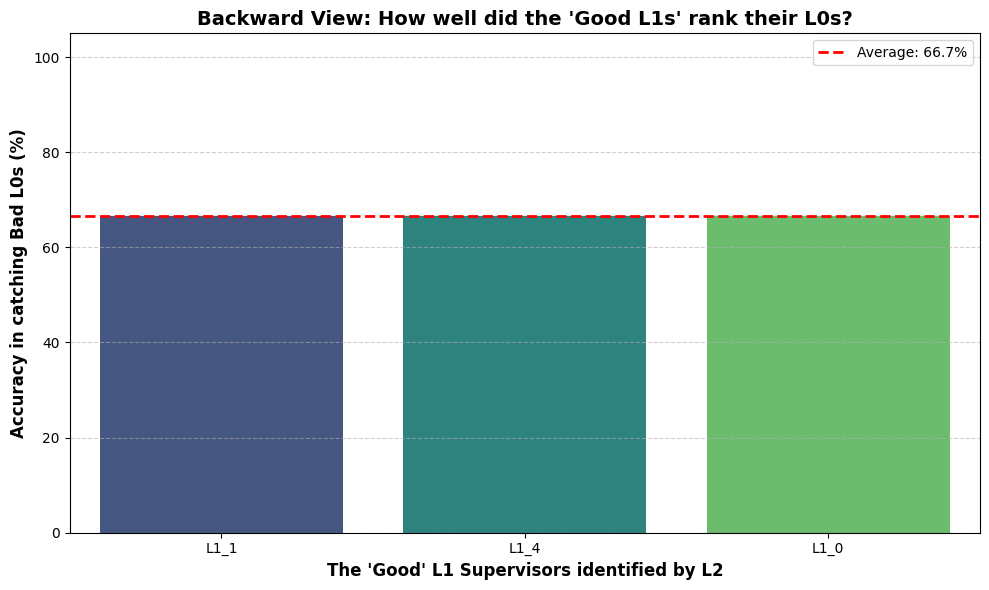

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your Generated Universe
file_path = r"C:\Users\CEGIS\Documents\GitHub\discsim\audit_dashboard\validation_results\single_universe_1_Bad_L0_Good_L1_rho_0.7.parquet"
df = pd.read_parquet(file_path)

TARGET_PERCENTILE = 0.30  # Targeting the Top 30%
indicator = 'haz' # Looking at Height

# Helper function to calculate MAE
def calculate_metrics(df, group_cols, col_meas, col_baseline):
    temp_df = df.copy()
    temp_df['_err'] = np.abs(temp_df[col_meas] - temp_df[col_baseline])
    return temp_df.groupby(group_cols)['_err'].mean().reset_index().rename(columns={'_err': 'MAE'})

# ==========================================
# STEP 1: L2 identifies the "Good L1s"
# ==========================================
# Calculate MAE between L2 (Auditor) and L1 (Supervisor)
l2_vs_l1 = calculate_metrics(df, ['L1_id'], f'L2_{indicator}', f'L1_{indicator}')

# Sort Ascending (Lowest MAE = Most honest/accurate Supervisor)
n_good_l1s = max(1, int(len(l2_vs_l1) * TARGET_PERCENTILE))
good_l1_list = l2_vs_l1.sort_values(by='MAE', ascending=True).head(n_good_l1s)['L1_id'].tolist()

print(f"🎯 L2 identified the Top {n_good_l1s} 'Good' Supervisors: {good_l1_list}")

# ==========================================
# STEP 2: Evaluate the L0 Accuracy of these "Good L1s"
# ==========================================
# Filter the universe to ONLY include the children belonging to the Good L1s
df_good_l1s = df[df['L1_id'].isin(good_l1_list)]

# Calculate the TRUE worst L0s under these Good L1s (God Mode)
god_l0 = calculate_metrics(df_good_l1s, ['L1_id', 'L0_id'], f'L0_{indicator}', f'real_{indicator}')

# Calculate what the Good L1s *thought* were their worst L0s
measured_l0 = calculate_metrics(df_good_l1s, ['L1_id', 'L0_id'], f'L1_{indicator}', f'L0_{indicator}')

# Determine the accuracy (Overlap percentage)
accuracies = []
for l1_id in good_l1_list:
    subset_god = god_l0[god_l0['L1_id'] == l1_id]
    subset_meas = measured_l0[measured_l0['L1_id'] == l1_id]
    
    # Target worst 30% of L0s per L1
    n_worst_l0s = max(1, int(len(subset_god) * TARGET_PERCENTILE))
    
    true_worst_l0s = set(subset_god.sort_values(by='MAE', ascending=False).head(n_worst_l0s)['L0_id'])
    measured_worst_l0s = set(subset_meas.sort_values(by='MAE', ascending=False).head(n_worst_l0s)['L0_id'])
    
    overlap = len(true_worst_l0s & measured_worst_l0s) / n_worst_l0s
    accuracies.append({'L1_id': l1_id, 'Accuracy': overlap * 100})

acc_df = pd.DataFrame(accuracies)

# ==========================================
# STEP 3: Plot the Backward View
# ==========================================
plt.figure(figsize=(10, 6), dpi=100)
sns.barplot(data=acc_df, x='L1_id', y='Accuracy', palette='viridis')

plt.axhline(y=acc_df['Accuracy'].mean(), color='red', linestyle='--', linewidth=2, label=f"Average: {acc_df['Accuracy'].mean():.1f}%")
plt.ylim(0, 105)
plt.xlabel("The 'Good' L1 Supervisors identified by L2", fontweight='bold', fontsize=12)
plt.ylabel("Accuracy in catching Bad L0s (%)", fontweight='bold', fontsize=12)
plt.title("Backward View: How well did the 'Good L1s' rank their L0s?", fontweight='bold', fontsize=14)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

imp 3 plots 

📊 Loading Data: Tracer_Master_DB_Height_Weight_20260522_142603.csv

Rendering Plot 6: Heatmap Matrix...


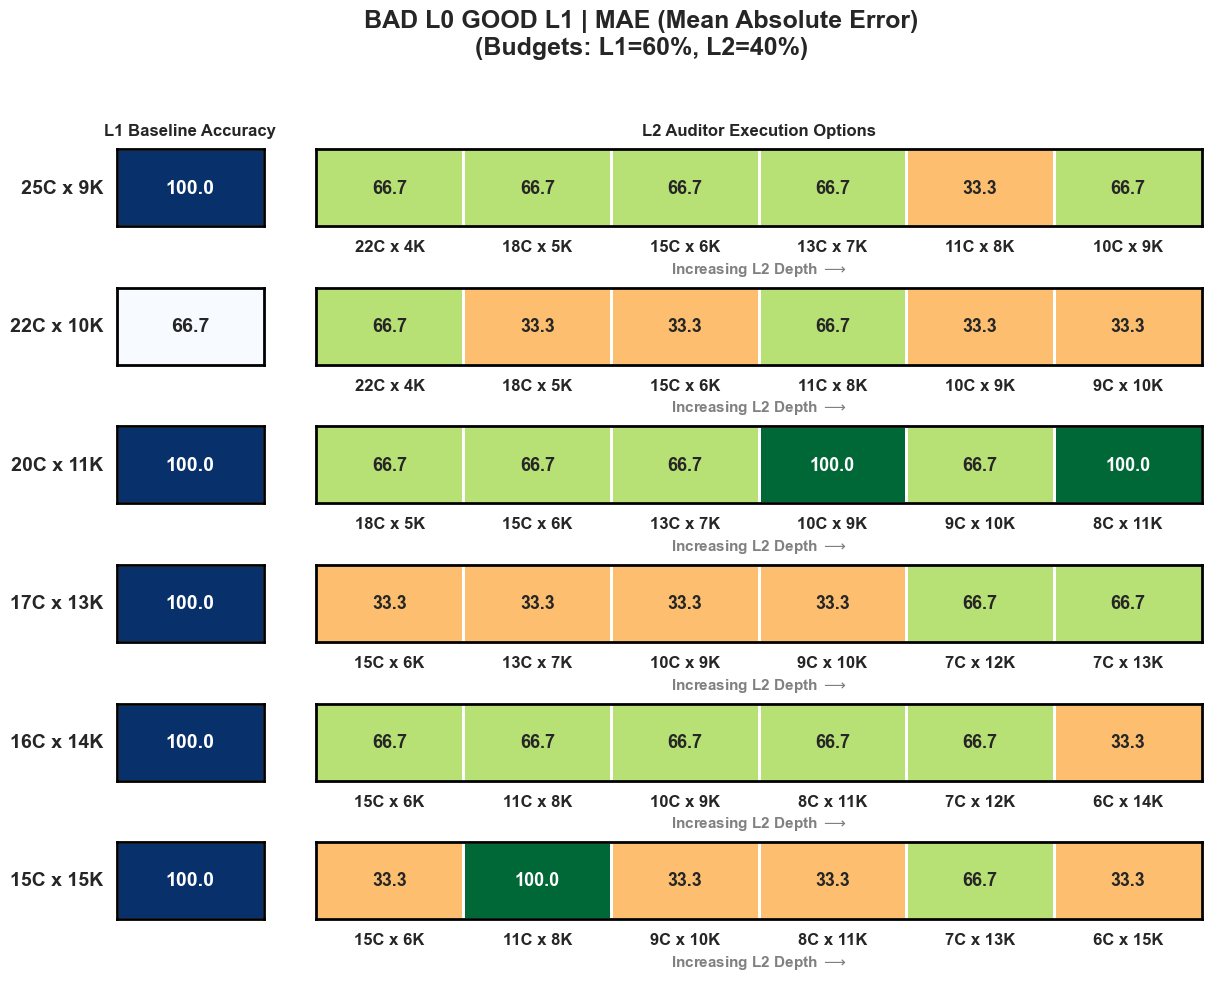


Rendering Plot 3: L1 Breadth vs Depth...


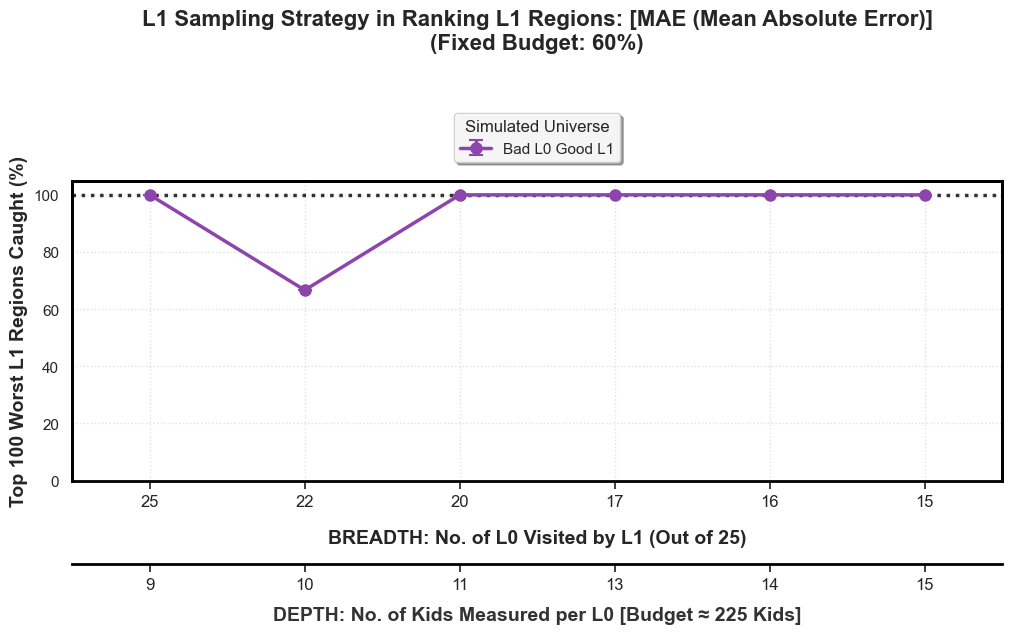


Rendering Plot 2: L1 Intra-Regional Accuracy...


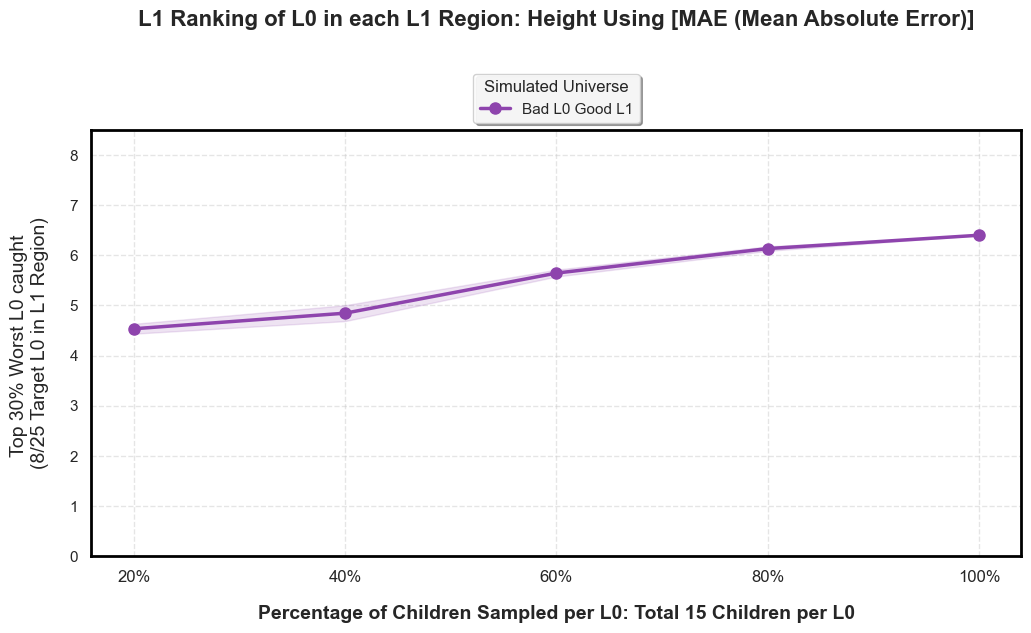

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import glob
import os

# ==============================================================================
# 1. SETUP & DATA LOADING
# ==============================================================================
# Point this to your actual validation folder
output_dir = r"C:\Users\CEGIS\Documents\GitHub\discsim\audit_dashboard\validation_results"
search_pattern = os.path.join(output_dir, "Tracer_Master_DB_Height_Weight_*.csv")

csv_files = glob.glob(search_pattern)
if not csv_files:
    raise FileNotFoundError("❌ No data found. Please check your folder path.")

latest_csv = max(csv_files, key=os.path.getctime)
print(f"📊 Loading Data: {os.path.basename(latest_csv)}")
df = pd.read_csv(latest_csv)

# Clean percentages to integers for plotting
df['L1_Pct_Num'] = df['L1_Budget_Pct'].str.replace('%', '').astype(int)
df['L2_Pct_Num'] = df['L2_Budget_Pct'].str.replace('%', '').astype(int)

# Rename universes to analytical names dynamically
df['Universe'] = "Unknown Universe"
df.loc[df['Scenario'].str.contains('Good_L0_Good_L1', case=False, na=False), 'Universe'] = "Good L0 Good L1"
df.loc[df['Scenario'].str.contains('Bad_L0_Lazy_L1', case=False, na=False), 'Universe'] = "Good L0 Bad L1"
df.loc[df['Scenario'].str.contains('Bad_L0_Good_L1', case=False, na=False), 'Universe'] = "Bad L0 Good L1"
df.loc[df['Scenario'].str.contains('Bad_L0_Corrupt_L1', case=False, na=False), 'Universe'] = "Bad L0 Bad L1"
df.loc[df['Scenario'].str.contains('Normal', case=False, na=False), 'Universe'] = "Normal"

# Filter for Height ONLY (Safely handles single universe testing)
df = df[df['Indicator'] == 'Height']

# Set up global variables needed for the plots
target_count = 100
v1_col = "V1_MAE_Acc"
v2_col = "V2_MAE_Acc"
v3_col = "V3_MAE_Acc"
selected_metric_label = "MAE (Mean Absolute Error)"

uni_colors = {
    "Good L0 Good L1": "#27ae60", 
    "Good L0 Bad L1": "#f1c40f", 
    "Normal": "#2980b9", 
    "Bad L0 Good L1": "#8e44ad", 
    "Bad L0 Bad L1": "#c0392b"
}

# ==============================================================================
# 2. PLOTTING FUNCTIONS
# ==============================================================================

def plot_6_heatmap(df, metric_col_l1, metric_col_l2, metric_label, selected_uni, l1_pct_str, l2_pct_str):
    vmin_global_l1, vmax_global_l1 = df[metric_col_l1].min(), df[metric_col_l1].max()
    vmin_global_l2, vmax_global_l2 = df[metric_col_l2].min(), df[metric_col_l2].max()

    df_hm = df[(df['Universe'] == selected_uni) & (df['L1_Budget_Pct'] == l1_pct_str) & (df['L2_Budget_Pct'] == l2_pct_str)].copy()
    if df_hm.empty: return None

    agg_df = df_hm.groupby(['L1_Label', 'L2_Label', 'L2_K']).agg(
        L1_Acc=(metric_col_l1, 'mean'), L2_Acc=(metric_col_l2, 'mean')
    ).reset_index()

    l1_order = sorted(agg_df['L1_Label'].unique(), key=lambda x: int(x.split('C')[0]), reverse=True)

    fig = plt.figure(figsize=(14, 10), dpi=100)
    gs = gridspec.GridSpec(nrows=len(l1_order), ncols=2, width_ratios=[1, 6], wspace=0.1, hspace=0.8)
    sns.set_theme(style="white")

    for i, l1_lbl in enumerate(l1_order):
        ax_l1 = fig.add_subplot(gs[i, 0]) 
        ax_l2 = fig.add_subplot(gs[i, 1]) 

        subset = agg_df[agg_df['L1_Label'] == l1_lbl].sort_values(by='L2_K')
        l1_acc_value = subset['L1_Acc'].iloc[0] if not subset.empty else 0
        
        sns.heatmap(np.array([[l1_acc_value]]), annot=True, fmt=".1f", cmap="Blues", 
                    cbar=False, linewidths=2, linecolor='white', vmin=vmin_global_l1, vmax=vmax_global_l1, 
                    ax=ax_l1, annot_kws={"size": 14, "weight": "bold"})

        ax_l1.set_xticks([])
        ax_l1.set_yticks([0.5])
        ax_l1.set_yticklabels([l1_lbl], rotation=0, fontsize=14, fontweight='bold')
        if i == 0: ax_l1.set_title("L1 Baseline Accuracy", fontsize=12, fontweight='bold', pad=10)

        heatmap_data_l2 = subset[['L2_Acc']].T 
        l2_labels = subset['L2_Label'].tolist()

        sns.heatmap(heatmap_data_l2, annot=True, fmt=".1f", cmap="RdYlGn", 
                    cbar=False, linewidths=2, linecolor='white', vmin=vmin_global_l2, vmax=vmax_global_l2, 
                    ax=ax_l2, annot_kws={"size": 13, "weight": "bold"})

        ax_l2.set_yticks([])
        ax_l2.set_xticks(np.arange(len(l2_labels)) + 0.5)
        ax_l2.set_xticklabels(l2_labels, rotation=0, fontsize=12, fontweight='bold')
        ax_l2.set_xlabel(r"Increasing L2 Depth $\longrightarrow$", fontsize=11, fontweight='bold', color='grey')
        if i == 0: ax_l2.set_title("L2 Auditor Execution Options", fontsize=12, fontweight='bold', pad=10)

        for ax in [ax_l1, ax_l2]:
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(2)
                spine.set_color('black')

    fig.suptitle(f"{selected_uni.upper()} | {metric_label}\n(Budgets: L1={l1_pct_str}, L2={l2_pct_str})", 
                 fontsize=18, fontweight='bold', y=1.02)
    return fig


def plot_3_bd_optimization(df, metric_col, metric_label, selected_unis, l1_budget_str):
    filtered_df = df[(df['Universe'].isin(selected_unis)) & (df['L1_Budget_Pct'] == l1_budget_str)].copy()
    if filtered_df.empty: return None

    agg_df = filtered_df.groupby(['Universe', 'L1_C', 'L1_K']).agg(
        mean_acc=(metric_col, 'mean'), std_acc=(metric_col, 'std'), count=(metric_col, 'count')
    ).reset_index()
    agg_df['std_acc'] = agg_df['std_acc'].fillna(0)
    agg_df['ci95'] = 1.96 * (agg_df['std_acc'] / np.sqrt(agg_df['count']))

    agg_df.sort_values(['Universe', 'L1_C'], ascending=[True, False], inplace=True)
    sample_uni = agg_df[agg_df['Universe'] == agg_df['Universe'].iloc[0]]
    if sample_uni.empty: return None

    x_indices = np.arange(len(sample_uni)) 
    x_breadth_labels = sample_uni['L1_C'].values.astype(int)
    x_depth_labels = sample_uni['L1_K'].values.astype(int)
    approx_kids = int(sample_uni['L1_C'].iloc[0] * sample_uni['L1_K'].iloc[0])

    fig, ax1 = plt.subplots(figsize=(12, 6), dpi=100)

    for uni in [u for u in uni_colors.keys() if u in agg_df['Universe'].unique()]:
        data = agg_df[agg_df['Universe'] == uni]
        ax1.errorbar(x_indices, data['mean_acc'], yerr=data['ci95'], 
                     fmt='o-', markersize=8, color=uni_colors[uni], linewidth=2.5, 
                     capsize=5, capthick=1.5, label=uni, zorder=5)

    ax1.axhline(y=target_count, color='black', linestyle=':', linewidth=2.5, alpha=0.8, zorder=3)
    ax1.set_xlim(min(x_indices) - 0.5, max(x_indices) + 0.5)
    ax1.set_xticks(x_indices)
    ax1.set_xticklabels(x_breadth_labels, fontsize=12) 
    ax1.set_xlabel('BREADTH: No. of L0 Visited by L1 (Out of 25)', fontsize=14, fontweight='bold', labelpad=15)
    ax1.set_ylabel(f'Top {target_count} Worst L1 Regions Caught (%)', fontsize=14, fontweight='bold')

    ax2 = ax1.twiny()
    ax2.xaxis.set_ticks_position('bottom')
    ax2.xaxis.set_label_position('bottom')
    ax2.spines['bottom'].set_position(('outward', 60)) 
    ax2.set_xlim(ax1.get_xlim())
    ax2.set_xticks(x_indices)
    ax2.set_xticklabels(x_depth_labels, fontsize=12)
    ax2.set_xlabel(f'DEPTH: No. of Kids Measured per L0 [Budget ≈ {approx_kids} Kids]', fontsize=14, fontweight='bold', color='#333333', labelpad=10)

    ax1.set_ylim(0, 105)
    ax1.grid(True, linestyle=':', alpha=0.6)

    for ax in [ax1, ax2]:
        for spine in ax.spines.values():
            spine.set_linewidth(2.0)
            spine.set_color('black')

    ax1.legend(title='Simulated Universe', bbox_to_anchor=(0.5, 1.25), loc='upper center', 
               ncol=5, fontsize=11, framealpha=0.9, shadow=True)
    plt.title(f"L1 Sampling Strategy in Ranking L1 Regions: [{metric_label}]\n(Fixed Budget: {l1_budget_str})", 
              fontsize=16, pad=95, fontweight='bold')

    plt.subplots_adjust(bottom=0.25, top=0.75) 
    return fig


def plot_2_intra_regional(df, metric_col, metric_label, selected_unis):
    filtered_df = df[df['Universe'].isin(selected_unis)]

    agg_df = filtered_df.groupby(['Universe', 'L1_Pct_Num']).agg(
        mean_acc=(metric_col, 'mean'), std_acc=(metric_col, 'std'), count=(metric_col, 'count')
    ).reset_index()
    agg_df['std_acc'] = agg_df['std_acc'].fillna(0)
    agg_df['ci95'] = 1.96 * (agg_df['std_acc'] / np.sqrt(agg_df['count']))

    TARGET_CLINICS = 8
    agg_df['mean_acc_count'] = agg_df['mean_acc'] * (TARGET_CLINICS / 100)
    agg_df['ci_95_count'] = agg_df['ci95'] * (TARGET_CLINICS / 100)

    fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

    for uni in [u for u in uni_colors.keys() if u in agg_df['Universe'].unique()]:
        data = agg_df[agg_df['Universe'] == uni].sort_values('L1_Pct_Num')
        ax.plot(data['L1_Pct_Num'], data['mean_acc_count'], marker='o', linestyle='-', 
                color=uni_colors[uni], label=uni, lw=2.5, ms=8)
        ax.fill_between(data['L1_Pct_Num'], data['mean_acc_count'] - data['ci_95_count'], 
                        data['mean_acc_count'] + data['ci_95_count'], color=uni_colors[uni], alpha=0.15)

    ax.set_xlabel('Percentage of Children Sampled per L0: Total 15 Children per L0', fontsize=14, fontweight='bold', labelpad=15)
    ax.set_ylabel(f'Top 30% Worst L0 caught \n({TARGET_CLINICS}/25 Target L0 in L1 Region)', fontsize=14, labelpad=15)

    x_ticks = sorted(agg_df['L1_Pct_Num'].unique())
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f"{x}%" for x in x_ticks], fontsize=12)
    ax.set_ylim(0, 8.5)
    ax.grid(True, linestyle='--', alpha=0.5)

    for spine in ax.spines.values():
        spine.set_linewidth(2.0)
        spine.set_color('black')

    ax.legend(title='Simulated Universe', bbox_to_anchor=(0.5, 1.15), loc='upper center', 
              ncol=5, fontsize=11, framealpha=0.9, shadow=True)
    plt.title(f"L1 Ranking of L0 in each L1 Region: Height Using [{metric_label}]", 
              fontsize=16, fontweight='bold', pad=75)
    plt.subplots_adjust(top=0.82)
    return fig


# ==============================================================================
# 3. RENDER THE PLOTS
# ==============================================================================

# PLOT 6: HEATMAP MATRIX
print("\n" + "="*50)
print("Rendering Plot 6: Heatmap Matrix...")
# You can change the universe, L1 budget, or L2 budget here to see different cross-sections
fig6 = plot_6_heatmap(df, v1_col, v3_col, selected_metric_label, selected_uni="Bad L0 Good L1", l1_pct_str="60%", l2_pct_str="40%")
plt.show()

# PLOT 3: BREADTH VS DEPTH
print("\n" + "="*50)
print("Rendering Plot 3: L1 Breadth vs Depth...")
universes_to_plot = ["Good L0 Good L1", "Bad L0 Good L1", "Bad L0 Bad L1"] # Only plotting 3 for a cleaner visual
fig3 = plot_3_bd_optimization(df, v1_col, selected_metric_label, selected_unis=universes_to_plot, l1_budget_str="60%")
plt.show()

# PLOT 2: INTRA-REGIONAL
print("\n" + "="*50)
print("Rendering Plot 2: L1 Intra-Regional Accuracy...")
fig2 = plot_2_intra_regional(df, v2_col, selected_metric_label, selected_unis=universes_to_plot)
plt.show()